# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

In [2]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch02


In [3]:
!python --version

Python 3.12.10


In [3]:
# !pip install keras keras-hub keras-nlp --upgrade -q

In [4]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

# Chapter 02 - The mathematical building blocks of neural networks
## 2.1 A first look at a neural network
page 17

<img src="../pics/mnist.png" width=400> 


### Loading the MNIST dataset in Keras

The MNIST dataset comes preloaded in Keras, in the form of a set of four NumPy arrays.

The labels are an array of digits, ranging from 0 to 9. The images and labels have a one-to-one correspondence.



In [10]:
from keras.datasets import mnist

In [11]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

#### Training Data

In [7]:
train_images.shape

(60000, 28, 28)

In [8]:
len(train_labels)

60000

In [9]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

#### Test Data


In [10]:
test_images.shape

(10000, 28, 28)

In [11]:
len(test_labels)

10000

In [12]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

#### The network architecture

In [13]:
import keras
from keras import layers

model = keras.Sequential(
    [layers.Dense(512, activation="relu"), layers.Dense(10, activation="softmax")]
)

#### The compilation step

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### Preparing the Image data

In [15]:
train_images = train_images.reshape((60_000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10_000, 28 * 28))
test_images = test_images.astype("float32") / 255

#### "Fitting" the model

In [16]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9239 - loss: 0.2666
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9680 - loss: 0.1099
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9794 - loss: 0.0713
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9847 - loss: 0.0510
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9896 - loss: 0.0370


#### Using the model to make predictions

In [17]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


array([5.08148162e-07, 8.83671945e-08, 1.07655011e-04, 3.71741713e-04,
       4.03453049e-09, 3.65365480e-07, 1.57704183e-10, 9.99493599e-01,
       1.39903295e-05, 1.20414898e-05], dtype=float32)

In [18]:
predictions[0].argmax()

np.int64(7)

In [19]:
predictions[0][7]

np.float32(0.9994936)

The first digit in our test has the highest probability score (0.9994936, almost 1) at index 7, so according to our model, it must be a 7.
We check it with our label.

In [20]:
test_labels[0]

np.uint8(7)

#### Evaluating the model on new data

In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0653
test_acc: 0.9789000153541565


## 2.2 Data representation for neural networks

### 2.2.1 Scalars (rank-0 tensors)
A tensor that contains only one number is called a `scalar` (or scalar tensor, rank-0 tensor, or 0D tensor). In NumPy, a `float32` or `floar64` number is a scalar tensor (or scalar array). You can display the number of axes of a NumPy tensor via the `ndim` attribute; a scalar tensor has 0 axes (`ndim == 0`). The number of axes of a tensor is also called its `rank`. Here's a NumPy scalar:

In [15]:
import numpy as np

x = np.array(12)
x

array(12)

In [23]:
x.ndim

0

### 2.2.2 Vectors (rank-1 tensors)
An array of numbers is called a `vector` (or rank-1 tensor o 1D tensor). A rank-1 tensor has exactly one axix. The following is a NumPy vector:

In [24]:
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [25]:
x.ndim

1

This vector has five entries and so is called a `5-dimensional vector`. Don't confuse with a 5D vector with a 5D tensor!. A 5D vector has only one axis and has five dimensions along its axis, whereas a 5D tensor has five axes (and may have any number of dimensions along each axis.)

### 2.2.3 Matrices (rank-2 tensors)
An array of vectors is a `matrix` (or rank-2 tensor or 2D tensor). A `matrix` has two axes (often referred to as `rows` and `columns`).

In [27]:
x = np.array([[5, 78, 2, 34, 0], [6, 79, 3, 35, 1], [7, 80, 4, 36, 2]])

In [29]:
x.ndim

2

The entries for the first axis are called the `rows`, and the entries for the second axis are called the `columns`. In the previous example, [5, 78, 2, 34, 0] is the first row of x, and [5, 6, 7] the first `column`.

### 2.2.4 Rank-3 tensors and higher-rank tensors
If you pack such `matrices` in a new array, you obtain a rank-3 tensor (or 3D tensor), which you can visually interpret as a cube of numbers. The following is a NumPy rank-3 tensor:

In [ ]:
x = np.array(
    [
        [[5, 78, 2, 34, 0], [6, 79, 3, 35, 1], [7, 80, 4, 36, 2]],
        [[5, 78, 2, 34, 0], [6, 79, 3, 35, 1], [7, 80, 4, 36, 2]],
        [[5, 78, 2, 34, 0], [6, 79, 3, 35, 1], [7, 80, 4, 36, 2]],
    ]
)
x.ndim

3

### 2.2.5 Key attributes
A `tensor` is defined by three key attributes:
* Number of axis (rank)

    For instance, a rank-3 `tensor` has three axes, and a `matrix` has two axes. This is also called the tensor's `ndim` in Pythgon libraries such as NumPy, JAX, TensorFlow, and PyTorch.

* Shape

    This is a tuple of integers that describes how many dimensions the tensor has along each axis. For instance, the previous matrix example has a shape (3, 5), and the rank-3 tensor example has shape (3, 3, 5). A vector has a shape with a single element, such as (5), whereas a scalar has an empty shape, ().

* Data type (usually called `dtype` in Python libraries)

    This is the type of the data contained in the tensor, for instance, a tensor's type could be `float16`, `float32`, `float64`, `uint8`, `bool`, and so on. In TensorFlow, you are also likely to come across `string` tensors.

In [31]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


Next, we display the number of axes of the tensor `train_images`, the `ndim` attribute:

In [32]:
train_images.ndim

3

Here's its shape:

In [33]:
train_images.shape

(60000, 28, 28)

And this is its data type, the `dtype` attribute:

In [34]:
train_images.dtype

dtype('uint8')

So what we have here is a rank-3 tensor of 8-bit integers. More precisely, it's an array of 60,000 matrices of 28 x 28 integers. Each such matrix is a grayscale image, with coefficient between 0 and 255.

Let's display the fourth digit in this rank-3 tensor, using the library Matplotlib (part of the standard scientific Python suite).

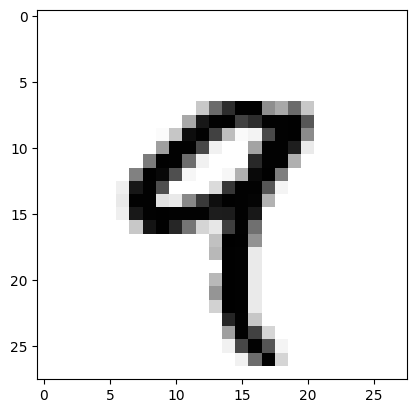

In [36]:
import matplotlib.pyplot as plt

digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

Naturally, the corresponding label is just the integer 9:

In [37]:
train_labels[4]

np.uint8(9)

### 2.2.6 Manipulating tensors in NumPy
In the previous example, we selected a specific digit alongside the first axis using the
syntax `train_images[i]`. Selecting specific elements in a tensor is called tensor slicing.
Let’s look at the tensor-slicing operations you can do on NumPy arrays.
The following example selects digits #10 to #100 (#100 isn’t included) and puts them
in an array of shape (90, 28, 28):

In [38]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In general, you may select slices between any two indices along each tensor axis. For
instance, to select 14 × 14 pixels in the bottom-right corner of all images, you would do
this:

In [39]:
my_slice = train_images[:, 14:, 14:]

It’s also possible to use negative indices. Much like negative indices in Python lists, they
indicate a position relative to the end of the current axis. To crop the images to patches
of 14 × 14 pixels centered in the middle, do this:

In [40]:
my_slice = train_images[:, 7:-7, 7:-7]

### 2.2.7 The notion of data batches
In general, the first axis (axis 0, because indexing starts at 0) in all data tensors you’ll
come across in deep learning will be the samples axis. In the MNIST example, “samples”
are images of digits.
In addition, deep learning models don’t process an entire dataset at once; rather,
they break the data into small “batches,” or groups of samples with a fixed size. Concretely,
here’s one batch of our MNIST digits, with a batch size of 128:

In [41]:
batch = train_images[:128]

And here's the next batch:

In [42]:
batch = train_images[128:256]

Ant the nth batch:

In [43]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

When considering such a batch tensor, the first axis (axis 0) is called the batch axis (or
batch dimension). You’ll frequently encounter this term when using Keras and other
deep learning libraries.

## 2.3 The gears of neural networks: Tensor operations

Just like any computer program can be ultimately reduced to a small set of binary operations
on binary inputs (AND, OR, NOR, and so on), all transformations learned by deep
neural networks can be reduced to a handful of tensor operations (or tensor functions)
applied to tensors of numeric data. For instance, it’s possible to add tensors, multiply
tensors, and so on.
In our initial example, we were building our model by stacking `Dense layers` on top of
each other. A Keras layer instance looks like this:

```python
    keras.layers.Dense(512, activation="relu")
```

This layer can be interpreted as a function, which takes as input a matrix and returns another matrix&mdash;a new representation for the input tensor. Specially, the function is as follows (where `W` is a matrix and `b` is a vector, both attributes of the layer):

```python
    output = relu(matmul(input, W) + b)
```

Let's unpack this. We have three tensor operations here:

* A tensor product `(matmul)` between the input tensor and a tensor named `W`.

* An addition `(+)` between the resulting `matrix` and a vector `b`.

* A `relu` operation: `relu(x)` is `max(x, 0)`. "`relu`" stands for "REctified Linear Unit".

### 2.3.1 Element-wise operation

The `relu` operation and addition are element-wise operations: operations that are
applied independently to each entry in the tensors being considered. This means
these operations are highly amenable to massively parallel implementations (vectorized
implementations, a term that comes from the vector processor supercomputer architecture
from the 1970–1990 period). If you want to write a naive Python implementation
of an element-wise operation, you use a for loop, as in this naive implementation of an
element-wise relu operation:

In [ ]:
def naive_relu(x):
    assert len(x.shape) == 2  # x is a rank-2 NumPy tensor
    x = x.copy()  # avoids overwriting the input tensor
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

You could do the same for addition:

In [ ]:
def naive_add(x, y):
    assert len(x.shape) == 2  # x and y are rank-2 NumPy tensors
    assert x.shape == y.shape
    x = x.copy()  # avoids overwriting the input tensor
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

So, in NumPy, you can do the following element-wise operation, and it will be blazing
fast:

```python
import numpy as np

z = x + y               # Elelment-wise addition
z = np.maximum(x, 0.0)  # Element-wise relu
```

Let's actually time the difference:

In [ ]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1_000):
    z = x + y
    z = np.maximum(z, 0.0)
print(f"Took: {time.time() - t0:.2f} s")


Took: 0.01 s


In [51]:
t0 = time.time()
for _ in range(1_000):
    z = naive_add(x, y)
    z = naive_relu(z)
print(f"Took: {time.time() - t0:.2f} s")


Took: 1.69 s


The NumPy version takes 0.01 seconds. Meanwhile, the naive version takes a stunning 1.69 seconds.

Likewise, when running JAX/TensorFlow/PyTorch code on a GPU, element-wise operations
are executed via fully vectorized CUDA implementations that can best utilize
the highly parallel GPU chip architecture.

### 2.3.2 Broadcasting

Our earlier naive implementation of `naive_add` only supports the addition of rank-2
tensors with identical shapes. But in the `Dense` layer introduced earlier, we added a
rank-2 tensor with a vector. What happens with addition when the shapes of the two
tensors being added differ?

When possible, and if there's no ambiguity, the smaller tensor will be `broadcast` to match the shape of the larger tensor. Broadcasting consits of two steps:

* Axes (called `broadcast axes`) are added to the smaller tensor to match the `ndim` of the larger tensor.

* The smaller tensor is repeated alonside these new axes to match the full shape of the larger tensor.

Let's look at a concrete example. Consider `X` with shape (32, 10) and `y` with shape (10,):

In [ ]:
import numpy as np

X = np.random.random((32, 10))  # X is a random matrix with shape (32, 10)
y = np.random.random((10,))  # y is a random vector with shape (10,)

First, we add an empty first axis to `y`, whose shape becomes (1, 10)

In [ ]:
y = np.expand_dims(y, axis=0)  # The shape of y is now (1, 10)

Then, we repeat `y` 32 times alongside this new axis, so that we end up with a tensor `Y` with shape (32, 10), where `Y[i, :] == y` for i in range(0, 32)

In [ ]:
Y = np.tile(
    y, (32, 1)
)  # Repeat y 32 times along axis 0 to obtain Y with shape (32, 10)

At this point, we can add X and Y because they have the same shape.
In terms of implementation, no new rank-2 tensor is created because that would be
terribly inefficient. The repetition operation is entirely virtual: it happens at the algorithmic
level rather than at the memory level. But thinking of the vector being repeated
32 times alongside a new axis is a helpful mental model. Here’s what a naive implementation
would look like:

In [ ]:
def naive_add_matrix_and_vector(x, y):
    assert len(x.shape) == 2  # x is a rank-2 NumPy tensor
    assert len(y.shape) == 1  # y is a NumPy vector
    assert x.shape[1] == y.shape[0]
    x = x.copy()  # avoids overwriting the input tensor
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

The following example applies the element-wise maximum operation to two tensors of
different shapes via broadcasting:

In [ ]:
import numpy as np

x = np.random.random((64, 3, 32, 10))  # x is a random tensor with shape (64, 3, 32, 10)
y = np.random.random((32, 10))  # y is a random tensor with shape (32, 10)
z = np.maximum(x, y)  # The output z has shape (64, 3, 32, 10) like x


### 2.3.3 Tensor product

The `tensor product`, also called `dot product` or `matmul` (short for “matrix multiplication”) is
one of the most common, most useful tensor operations.
In NumPy, a tensor product is done using the `np.matmul` function, and in Keras, with
the `keras.ops.matmul` function. Its shorthand is the `@` operator in Python:

In [ ]:
x = np.random.random((32,))
y = np.random.random((32,))

z = np.matmul(x, y)  # takes the product between x and y
z = x @ y  # this is equivalent


In mathematical notation, you’d note the operation with a dot (•) (hence the name
“dot product”):

z = x • y

Mathematically, what dows the `matmul` operation do? Let's start with the product of two vectors x and y. It's computed as follows:

In [ ]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1  # x and y are NumPy vectors
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[y]
    return z


You'll have noticed that the product between two vectors is a scalar and that only vectors with the same number of elements are compatible for this operation.

You can also take the product between a `matrix x` and a `vector y`, which returns a `vector`
where the coefficients are the products between y and the rows of x. You implement
it as follows:

In [ ]:
def naive_matrix_vector_product(x, y):
    assert len(x.shape) == 2  # x is a NumPy matrix
    assert len(y.shape) == 1  # y is a NumPy vector
    assert x.shape[1] == y.shape[0]  # equal the 0th dimension of y
    z = np.zeros(
        x.shape[0]
    )  # this operation returns a vector of 0s with as many rows as c
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z


You could also reuse the code we wrote previously, which highlights the relationship
between a matrix-vector product and a vector product:

In [6]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z


Note that as soon as one of the two tensors has an `ndim` greater than 1, `matmul` is no longer
symmetric, which is to say that `matmul(x, y)` isn’t the same as` matmul(y, x)`.
Of course, a tensor product generalizes to tensors with an arbitrary number of axes.
The most common applications may be the product between two matrices. You can
take the product of two matrices `x` and `y` `(matmul(x, y))` if and only if `x.shape[1] ==
y.shape[0]`. The result is a matrix with shape` (x.shape[0], y.shape[1])`, where the
coefficients are the vector products between the rows of `x` and the columns of `y`. Here’s
the naive implementation:

In [ ]:
def naive_matrix_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2  # x and y are NumPy matrices
    assert (
        x.shape[1] == y.shape[0]
    )  # the 1st dimension of x must equal the 0th dimension of y
    z = np.zeros(
        (x.shape[0], y.shape[1])
    )  # this operation returns a matrix of 0s with a specific shape
    for i in range(x.shape[0]):  # iterates over the rowx of x ...
        for j in range(y.shape[i]):  # ... and over the columns of y
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z


### 2.3.4 Tensor reshaping

A third type of tensor operation that's essential to understand is `tensor reshaping`. Although it wasn't used in the `Dense` layers in our first neural network example, we used it when we preprocessed the digits data before feeding into our model:


In [13]:
train_images = train_images.reshape((60_000, 28 * 28))


Reshaping a tensor means rearranging its rows and columns to match a target shape. Naturally, the reshaped tensor has the same total number of coefficients as the initial tensor. Reshaping is best understood via simple examples:


In [19]:
x = np.array([[0.0, 1.0], [2.0, 3.0], [4.0, 5.0]])
x

array([[0., 1.],
       [2., 3.],
       [4., 5.]])

In [20]:
x.shape

(3, 2)

In [21]:
x = x.reshape((6, 1))
x

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]])

In [22]:
x = x.reshape((2, 3))
x

array([[0., 1., 2.],
       [3., 4., 5.]])

A special case of reshaping that's commonly encountered is `transposition`. `Transposing` a matrix means exchanging its rows and its columns, so that `x[i, :]` becomes `x[:, i]` 

In [ ]:
x = np.zeros((300, 20))  # creates an all-zeros matrix of shape(300, 20)
x = np.transpose(x)
x.shape

(20, 300)